In [1]:
import os
import random
import zipfile
import time
import shutil

from mmengine.runner import load_checkpoint
from sklearn.model_selection import ShuffleSplit
import torch
import torch.nn as nn
from PIL import Image
from sympy import print_tree
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import ToTensor, Compose, Normalize, RandomCrop, Resize, RandomAdjustSharpness, RandomHorizontalFlip, ColorJitter
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import OneHotEncoder


torch.random.manual_seed(50)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
zipped_folder = "archive.zip"
destination_folder = "Dataset"


os.makedirs(destination_folder, exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("Dataset/train", exist_ok=True)
os.makedirs("Dataset/test", exist_ok=True)


with zipfile.ZipFile(zipped_folder, "r") as zip_ref:
    zip_ref.extractall(destination_folder)

In [ ]:

file_list = []
label_list = []
path = "Dataset/data"


for root, dir, files in os.walk(path):
    for file in files:
        if file.endswith("jpg"):
            file_list.append(os.path.join(root, file))
            label = 1 if root.split("/")[-1] == "with_mask" else 0
            label_list.append(label)


In [ ]:
print(len(file_list))

In [ ]:
fold_list= []
splitter = ShuffleSplit(15, test_size=0.2, random_state=42)

for idx, (train_indices, test_indices) in enumerate(splitter.split(file_list)):
    fold_list.append({
        "train" : train_indices,
        "test" : test_indices
    })

In [ ]:
fold_list[5]

In [ ]:
idx =  9
test_indices, train_indices = fold_list[idx]["test"], fold_list[idx]["train"]
test_indices[0]

In [ ]:
plt.scatter([i for i in range(len(test_indices))], test_indices)
plt.show()

In [ ]:
plt.scatter([i for i in range(len(train_indices))], train_indices)
plt.show()

In [ ]:
file_list.index(file_list[10])

In [ ]:
destination_folder = None
sample_length = len(file_list)
sample_list = random.sample(file_list, sample_length)
#test_indices
#train_indices

for old_idx, file in enumerate(file_list):
    new_idx = sample_list.index(file)


    if old_idx in test_indices:
        destination_folder = "Dataset/test"
    elif old_idx in train_indices:
        destination_folder = "Dataset/train"
    else:
        print(f"idx {old_idx} not found in file list")

    filename = file.split("/")[-1]
    label = filename.split("_")[0]

    src = os.path.join(destination_folder, f"{filename}")
    dst = os.path.join(destination_folder, f"fmd_{new_idx}_{label}.jpg")

    shutil.move(file, destination_folder)
    os.rename(src, dst)



In [ ]:
ls

In [2]:
 class ImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.image_list = []
        self.label_list = []
        encoder = OneHotEncoder()

        for root, dirs, files in os.walk(root):
            for filename in files:
                if filename.endswith(".jpg"):

                    file_path = os.path.join(root, filename)

                    label =  filename.split(".")[-0].split("_")[-1]
                    label_id = 1 if label == "with" else 0


                    self.image_list.append(file_path)
                    self.label_list.append(label_id)






    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        image_filename= self.image_list[idx]
        label = self.label_list[idx]
        image = Image.open(image_filename).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label



In [3]:
input_image_shape = (224, 224)
transform = Compose([
    Resize(input_image_shape),
    RandomHorizontalFlip(),
    RandomAdjustSharpness(2, p=0.2, ),
    ColorJitter(),
    ToTensor(),
    Normalize((.5, .5, .5), (.5, .5, .5)),

])

view_transform = Compose([
    Resize(input_image_shape),
])


test_folder = "Dataset/test"
train_folder = "Dataset/train"

train_set_view = ImageDataset(train_folder, transform=view_transform)
test_set_view = ImageDataset(test_folder, transform=view_transform)
train_set  = ImageDataset(train_folder, transform=transform)
test_set  = ImageDataset(test_folder, transform=transform)



len(train_set), len(test_set)

(6042, 1511)

In [ ]:
sample_list = torch.randint(len(train_set_view), (1,10))

for i in sample_list[0]:
    image, label = train_set_view[i]
    image = view_transform(image)
    plt.imshow(image)
    print(label)
    plt.grid(False)
    plt.axis('off')
    plt.show()

output size = (h + 2*P -D*(K - 1) - 1) / S

In [2]:

class  FaceMaskDetector(nn.Module):
    def __init__(self):
        super(FaceMaskDetector, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=(5, 5), stride=1, padding=("same"), bias=False),
            nn.BatchNorm2d(64),
            nn.PReLU(),
            nn.Dropout(p=0.4),
            nn.AdaptiveAvgPool2d((1, 1)),

            nn.Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(3, 3), bias=False),
            nn.BatchNorm2d(128),
            nn.PReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Dropout(p=0.4),

            nn.Conv2d(128, 256, kernel_size=(5, 5), stride=(2, 2), padding=(3, 3), bias=False),
            nn.BatchNorm2d(256),
            nn.PReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Dropout(p=0.4),

        )

        self.fcn = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256, 512),
            nn.PReLU(),
            nn.Dropout(p=0.2),

            nn.Linear(512, 256),
            nn.PReLU(),
            nn.Dropout(p=0.2),


            nn.Linear(256, 32),
            nn.PReLU(),

            nn.Linear(32, 1),
        )
    def forward(self, x):
        x = self.conv(x)
        x = self.fcn(x)
        return x



In [3]:
def load_checkpoints(checkpoints_folder):
    global model

    epoch = 1

    model, criterion = FaceMaskDetector(),  nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    checkpoints_list = None

    if os.path.isdir(checkpoints_folder):
        checkpoints_list = sorted(list(os.listdir(checkpoints_folder)))

        if len(checkpoints_list) > 0:
            checkpoints_filename = os.path.join("checkpoints", checkpoints_list[0])
            if os.path.isfile(checkpoints_filename):

                checkpoints = torch.load(checkpoints_filename)
                model.load_state_dict(checkpoints["model_state_dict"])
                optimizer.load_state_dict(checkpoints["optimizer_state_dict"])
                epoch = checkpoints["epoch"] +1

                print(f"Resuming  training from epoch {epoch}")

            else:
                print(f"No checkpoint file found at {checkpoints_filename}")

        else:
            print("No  Checkpoint found , Restarting training from epoch 0")

    return model, optimizer, criterion, epoch


In [4]:
def plot_result(train_losses, test_losses, train_accuracy_list, test_accuracy_list):
    epoch_range = [i for i in range(1, len(train_accuracy_list) + 1, 1)]
    plt.plot(epoch_range, train_losses, label="Train Loss",)
    plt.plot(epoch_range, test_losses, label="Test Loss")
    plt.plot(epoch_range, train_accuracy_list, label="Train Accuracy")
    plt.plot(epoch_range, test_accuracy_list, label="Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Performance")
    plt.legend()
    plt.show()

def save_checkpoints(model, optimizer, epoch, metrics):
    checkpoints_filename = os.path.join("checkpoints", f"checkpoint_{epoch}.pth")
    checkpoint = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": epoch,
        "metrics": metrics
    }

    torch.save(checkpoint, checkpoints_filename)
    print(f"saved checkpoint at {checkpoints_filename}")



In [5]:
def display_sample(sample_list):
    label_dict = {
        1 : "with mask",
        0 : " Without mask"
    }
    for idx, ((image, label), labels, predicted_label) in enumerate(sample_list):

        image = np.asarray(image)
        print(f"Label --> {label_dict[int(label)]} | Predicted label --> {label_dict[int(predicted_label)]}")

        plt.imshow(image)
        plt.grid(False)
        plt.axis('off')
        plt.show()


In [7]:


def train(num_epochs, train_loader, test_loader, test_set):
    global  model

    train_losses = []
    test_losses = []
    train_accuracy_list = []
    test_accuracy_list = []

    model, optimizer, criterion, last_epoch = load_checkpoints(checkpoints_folder)
    model = model.to(device)

    # OPtimzer to Device


    for state in optimizer.state.values():
        for k, v in state.items():
            if isinstance(v, torch.Tensor):
                state[k] = v.to(device)

    for epoch in range(last_epoch, num_epochs+1):
        model.train()
        train_loss, correct, total = 0, 0, 0


        # ------------------------------------------------------
        # Training Phase
        #-------------------------------------------------------
        for images, labels in train_loader:
            optimizer.zero_grad()
            images, labels = images.to(device), labels.to(device).float()

            output_logits = model(images).view(-1)
            loss = criterion(output_logits, labels)

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            preds = (torch.sigmoid(output_logits) > 0.5).int()
            correct +=(preds==labels.int()).sum().item()
            total += labels.size(0)

        train_loss /= len(train_loader)
        train_accuracy = correct / total



        # ------------------------------------------------------
        # Test Phase
        #-------------------------------------------------------

        model.eval()
        sample_list = []
        test_loss,  correct, total, test_accuracy = 0, 0, 0, 0
        with torch.no_grad():
            for idx, (test_images, test_labels) in enumerate(test_loader):
                test_images, test_labels = test_images.to(device), test_labels.to(device).float()

                output_logits = model(test_images).view(-1)

                loss = criterion(output_logits, test_labels)

                predicted_label = (torch.sigmoid(output_logits) > 0.5).int()

                correct += (predicted_label == test_labels.int()).sum().item()
                test_loss += loss.item()
                total += test_labels.size(0)


                # Display Sample
                #---------------------------------------
                if idx == 0:
                    sample_list = zip(test_set_view, test_labels.cpu(), predicted_label.cpu())
                # -------------------------------------------


        test_loss /= len(test_loader)
        test_accuracy =   correct / total




        #--------------------
        # Append
        #-------------------

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accuracy_list.append(train_accuracy)
        test_accuracy_list.append(test_accuracy)

        print(
            "---------------------------------------------------------------------------------------------\n"
            f"Epoch [{epoch} /{num_epochs}]  | Train Loss  --> {train_loss:.5f} | Train Accuracy --> {train_accuracy:.5f} | Test Accuracy --> {test_accuracy:.5f}] | test loss --> {test_loss:.5f} |\n"
            "---------------------------------------------------------------------------------------------\n"
        )
        display_sample(sample_list)



        if (epoch) % 20 == 0:

            save_checkpoints(model, optimizer, epoch, train_accuracy)
            plot_result(train_losses, test_losses, train_accuracy_list, test_accuracy_list)


    return train_losses, test_losses, train_accuracy_list, test_accuracy_list




In [8]:
# Hyper parameter

batch_size = 50
learning_rate = 0.001
epochs = 400
betas = 0.999



In [ ]:
checkpoints_folder = "checkpoints"

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

print(len(train_set), len(test_set), len(train_loader), len(test_loader))

In [86]:

#train(epochs, train_loader, test_loader, test_set)
learning_rate = 0.0008

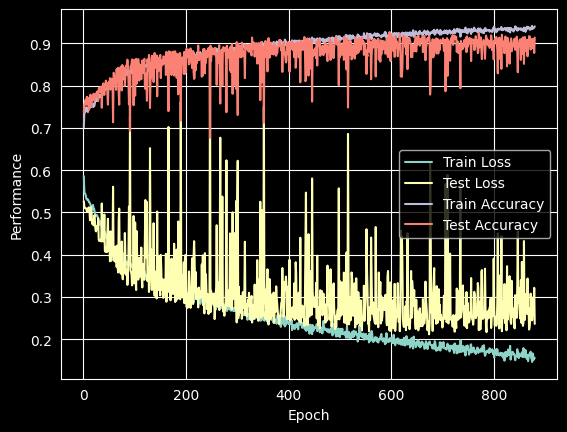

In [9]:
checkpoints_folder = "checkpoints"

file_name = os.path.join(checkpoints_folder, "checkpoint_880.pth")
checkpoints = torch.load(file_name)
model = FaceMaskDetector()
model.load_state_dict(checkpoints["model_state_dict"])
epoch = checkpoints["epoch"]
metrics = checkpoints["metrics"]

train_accuracy_list, test_accuracy_list, train_losses, test_losses = metrics

plot_result(train_losses, test_losses, train_accuracy_list, test_accuracy_list)

In [31]:
v  torch.tensor([i for i in model.parameters()], device=device)

ValueError: only one element tensors can be converted to Python scalars

In [33]:
y = [x for x in model.parameters()]

In [43]:
for idx, x in enumerate(y):
    #print(f"{idx} len --> {len(x)} --> {x}")
    print(x.shape)

    x = x.detach().numpy()

    print(x.ndim)

torch.Size([64, 3, 5, 5])
4
torch.Size([64])
1
torch.Size([64])
1
torch.Size([1])
1
torch.Size([128, 64, 5, 5])
4
torch.Size([128])
1
torch.Size([128])
1
torch.Size([1])
1
torch.Size([256, 128, 5, 5])
4
torch.Size([256])
1
torch.Size([256])
1
torch.Size([1])
1
torch.Size([512, 256])
2
torch.Size([512])
1
torch.Size([1])
1
torch.Size([256, 512])
2
torch.Size([256])
1
torch.Size([1])
1
torch.Size([32, 256])
2
torch.Size([32])
1
torch.Size([1])
1
torch.Size([1, 32])
2
torch.Size([1])
1


In [48]:
x = y[0]
y

[Parameter containing:
 tensor([[[[ 2.4602e-02,  9.6405e-02,  1.0783e-01, -4.2206e-03,  4.7283e-02],
           [ 5.9129e-02,  9.4769e-02,  3.1641e-02, -4.1875e-03,  5.7001e-02],
           [-8.5797e-02, -1.1332e-01,  7.6093e-02, -1.6949e-02, -2.0455e-02],
           [-1.1116e-01, -7.4539e-02,  5.3957e-02, -5.8223e-02,  6.9447e-02],
           [-1.3872e-01, -1.3731e-01, -2.4388e-03,  2.0198e-02,  1.8993e-02]],
 
          [[ 3.7225e-02,  1.0144e-01, -4.9894e-02,  6.6642e-02, -9.0612e-02],
           [-3.3308e-02, -3.8513e-02,  2.7086e-02, -8.7664e-02, -5.4179e-02],
           [ 7.0451e-02,  7.0181e-02,  6.7387e-02, -2.7613e-02,  5.0733e-02],
           [-1.2091e-03,  4.4758e-02, -7.4253e-02, -2.0546e-02, -4.6348e-02],
           [ 2.5027e-02,  3.4598e-02, -4.1745e-02,  1.7224e-02,  1.1640e-02]],
 
          [[ 5.0571e-02, -2.3683e-02, -1.1197e-01, -6.8313e-02, -7.9266e-02],
           [ 5.1901e-02, -7.2485e-02, -1.1679e-02, -7.5942e-02,  9.0519e-02],
           [ 9.4224e-02, -1.3677e-0

In [50]:
x.shape

torch.Size([64, 3, 5, 5])